# Compare Benchmark Charts

**Purpose:**
- Read Notebook 2 artifacts
- Generate comparison tables and charts without loading models
- Enforce schema validation

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
if _cwd.name != "notebooks":
    sys.path.insert(0, str(_cwd / "notebooks"))

from utils import setup_root
ROOT = setup_root()

Project root: /data/Projects/CCDF


## Locate latest completed run

In [2]:
import json

try:
    with open(ROOT / "results/charts/notebook_demo/latest_run.json", "r") as f:
        latest_run = json.load(f)
except FileNotFoundError:
    raise FileNotFoundError("latest_run.json not found. Please run Notebook 02 first.")

RUN_ID = latest_run["run_id"]
DATASET = latest_run["dataset"]
print(f"Latest run ID: {RUN_ID} (Dataset: {DATASET})")

Latest run ID: 20260710T095819Z (Dataset: gsm8k)


## Load and validate artifacts

In [3]:
import pandas as pd

CSV_PATH = ROOT / latest_run["table_dir"] / "comparison.csv"
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Missing comparison.csv at {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

required_cols = ["condition", "display_name", "original_input_tokens", "output_tokens", "steady_state_e2e_ms", "generation_tok_s", "peak_allocated_gib", "peak_reserved_gib"]
for c in required_cols:
    assert c in df.columns, f"Missing required column: {c}"
print("Artifact loaded and validated successfully. Each condition was measured in an isolated fresh process.")

Artifact loaded and validated successfully. Each condition was measured in an isolated fresh process.


## Show concise comparison table

In [4]:
metrics_mapping = [
    ("original_input_tokens", "Original input tokens", "{:.0f}"),
    ("compressed_input_tokens", "Compressed input tokens", "{:.0f}"),
    ("compression_retained_ratio", "Compression retained ratio", "{:.4f}"),
    ("compression_reduction_pct", "Compression reduction %", "{:.2f}%"),
    ("compression_factor", "Compression factor", "{:.4f}"),
    ("output_tokens", "Output tokens", "{:.0f}"),
    ("cap_hit", "Cap hit", "{}"),
    ("t_model_load_ms", "Model load time (ms)", "{:.2f}"),
    ("t_warmup_ms", "Warm-up time (ms)", "{:.2f}"),
    ("t_compress_ms", "Compression time (ms)", "{:.2f}"),
    ("t_prefill_ms", "Prefill time (ms)", "{:.2f}"),
    ("t_generation_ms", "Generation time (ms)", "{:.2f}"),
    ("steady_state_e2e_ms", "Steady-state E2E (ms)", "{:.2f}"),
    ("cold_start_e2e_ms", "Cold-start E2E (ms)", "{:.2f}"),
    ("generation_tok_s", "Generation tok/s", "{:.2f}"),
    ("e2e_tok_s", "E2E tok/s", "{:.2f}"),
    ("peak_allocated_gib", "Peak allocated VRAM (GiB)", "{:.4f}"),
    ("peak_reserved_gib", "Peak reserved VRAM (GiB)", "{:.4f}"),
    ("finish_reason", "Finish reason", "{}"),
    ("run_status", "Status", "{}")
]

formatted_data = {}
conditions = ["baseline_ar", "dflash_r1", "cc_dflash_r2"]
cond_names = {
    "baseline_ar": "Baseline-AR",
    "dflash_r1": "DFlash-R1",
    "cc_dflash_r2": "CC-DFlash-R2"
}

for c in conditions:
    formatted_data[cond_names[c]] = []

metric_names = []
for col_name, display_label, fmt in metrics_mapping:
    metric_names.append(display_label)
    for c in conditions:
        row_match = df[df["condition"] == c]
        if row_match.empty:
            val = "N/A"
        else:
            val = row_match.iloc[0].get(col_name)
            if pd.isna(val) or val == "" or val == "—":
                val = "—"
        
        if c in ["baseline_ar", "dflash_r1"] and col_name in ["compressed_input_tokens", "compression_retained_ratio", "compression_reduction_pct", "compression_factor"]:
            val = "—"
        elif c in ["baseline_ar", "dflash_r1"] and col_name in ["t_compress_ms", "t_warmup_ms", "t_model_load_ms"]:
            val = "0" if col_name == "t_compress_ms" else val
        
        if val != "—" and val != "N/A":
            try:
                val = fmt.format(float(val))
            except ValueError:
                val = fmt.format(val)
        
        formatted_data[cond_names[c]].append(val)

df_pivot = pd.DataFrame(formatted_data, index=metric_names)
display(df_pivot)

,Baseline-AR,DFlash-R1,CC-DFlash-R2
Original input tokens,103,103,103
Compressed input tokens,—,—,94
Compression retained ratio,—,—,0.3750
Compression reduction %,—,—,62.50%
Compression factor,—,—,2.6667
Output tokens,128,128,128
Cap hit,1.0,1.0,1.0
Model load time (ms),5423.70,6030.84,6546.78
Warm-up time (ms),4496.08,2708.56,4876.60
Compression time (ms),0.00,0.00,54.66


## Build composite dashboard

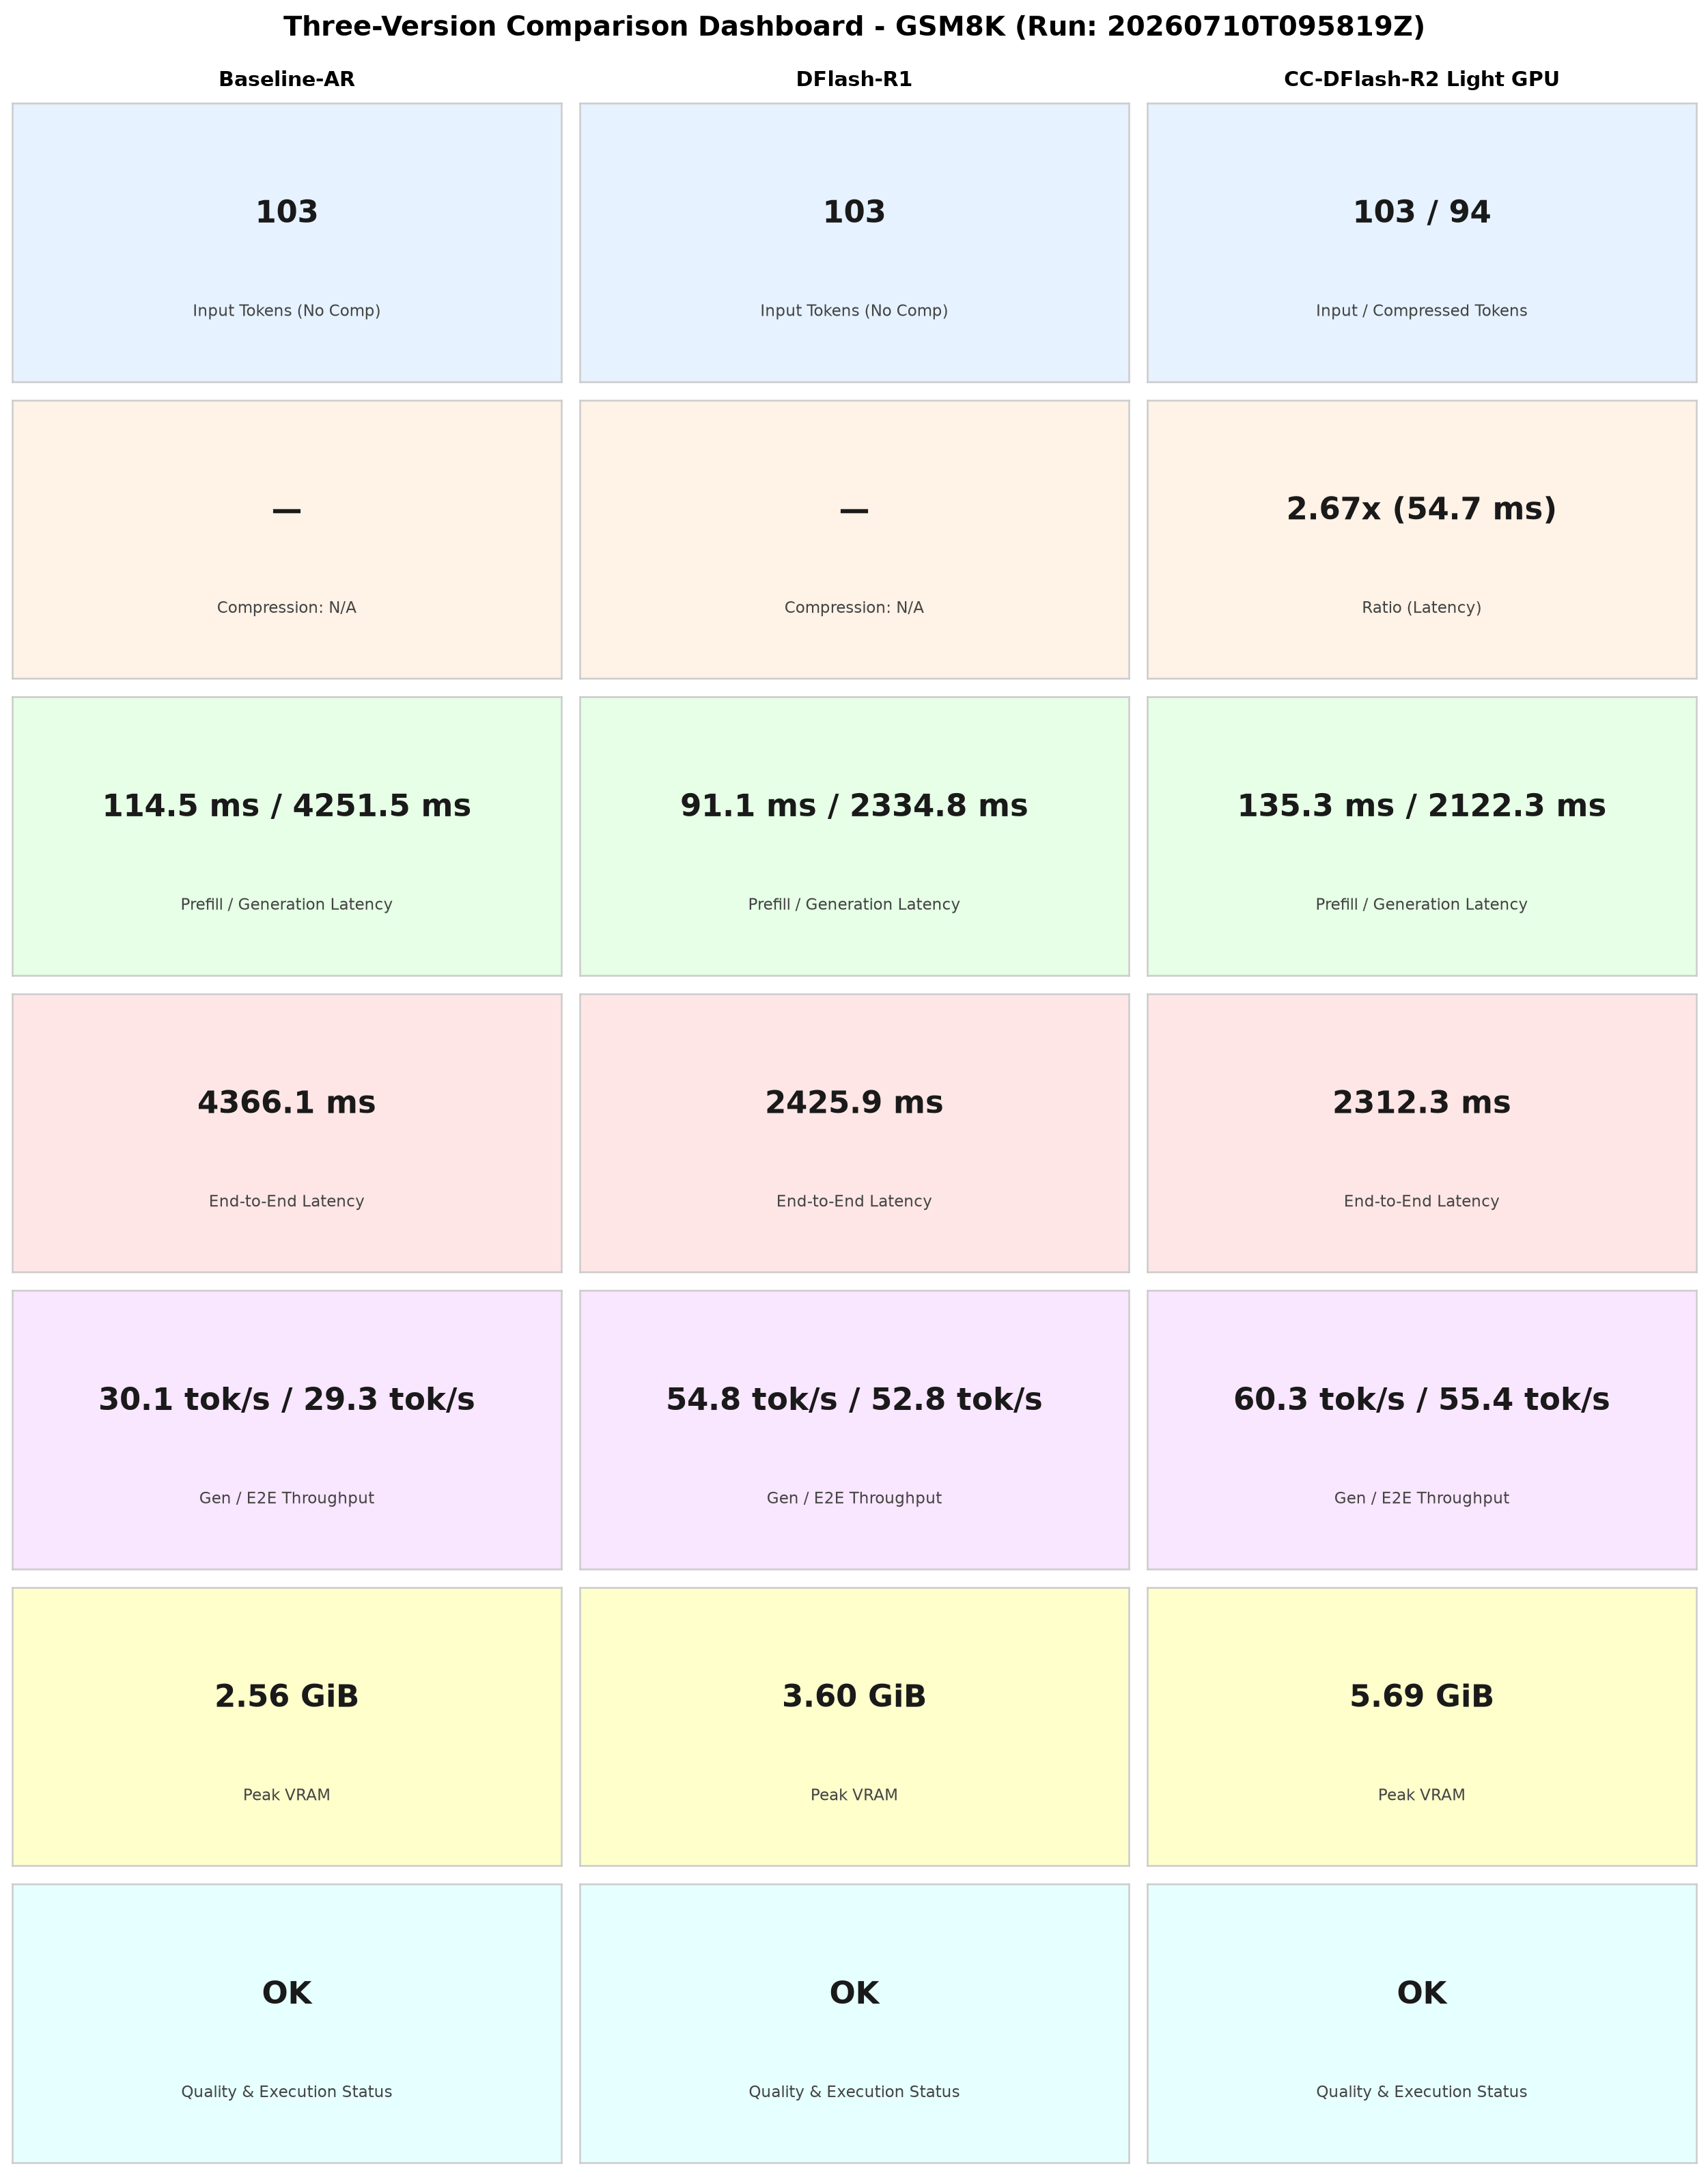

In [5]:
import matplotlib.pyplot as plt
from ccdf.demo.charting import build_three_version_dashboard

FIGURE_DIR = ROOT / latest_run["figure_dir"]
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

dashboard_figure = build_three_version_dashboard(
    df,
    dataset=DATASET,
    run_id=RUN_ID
)

## Display and save composite dashboard

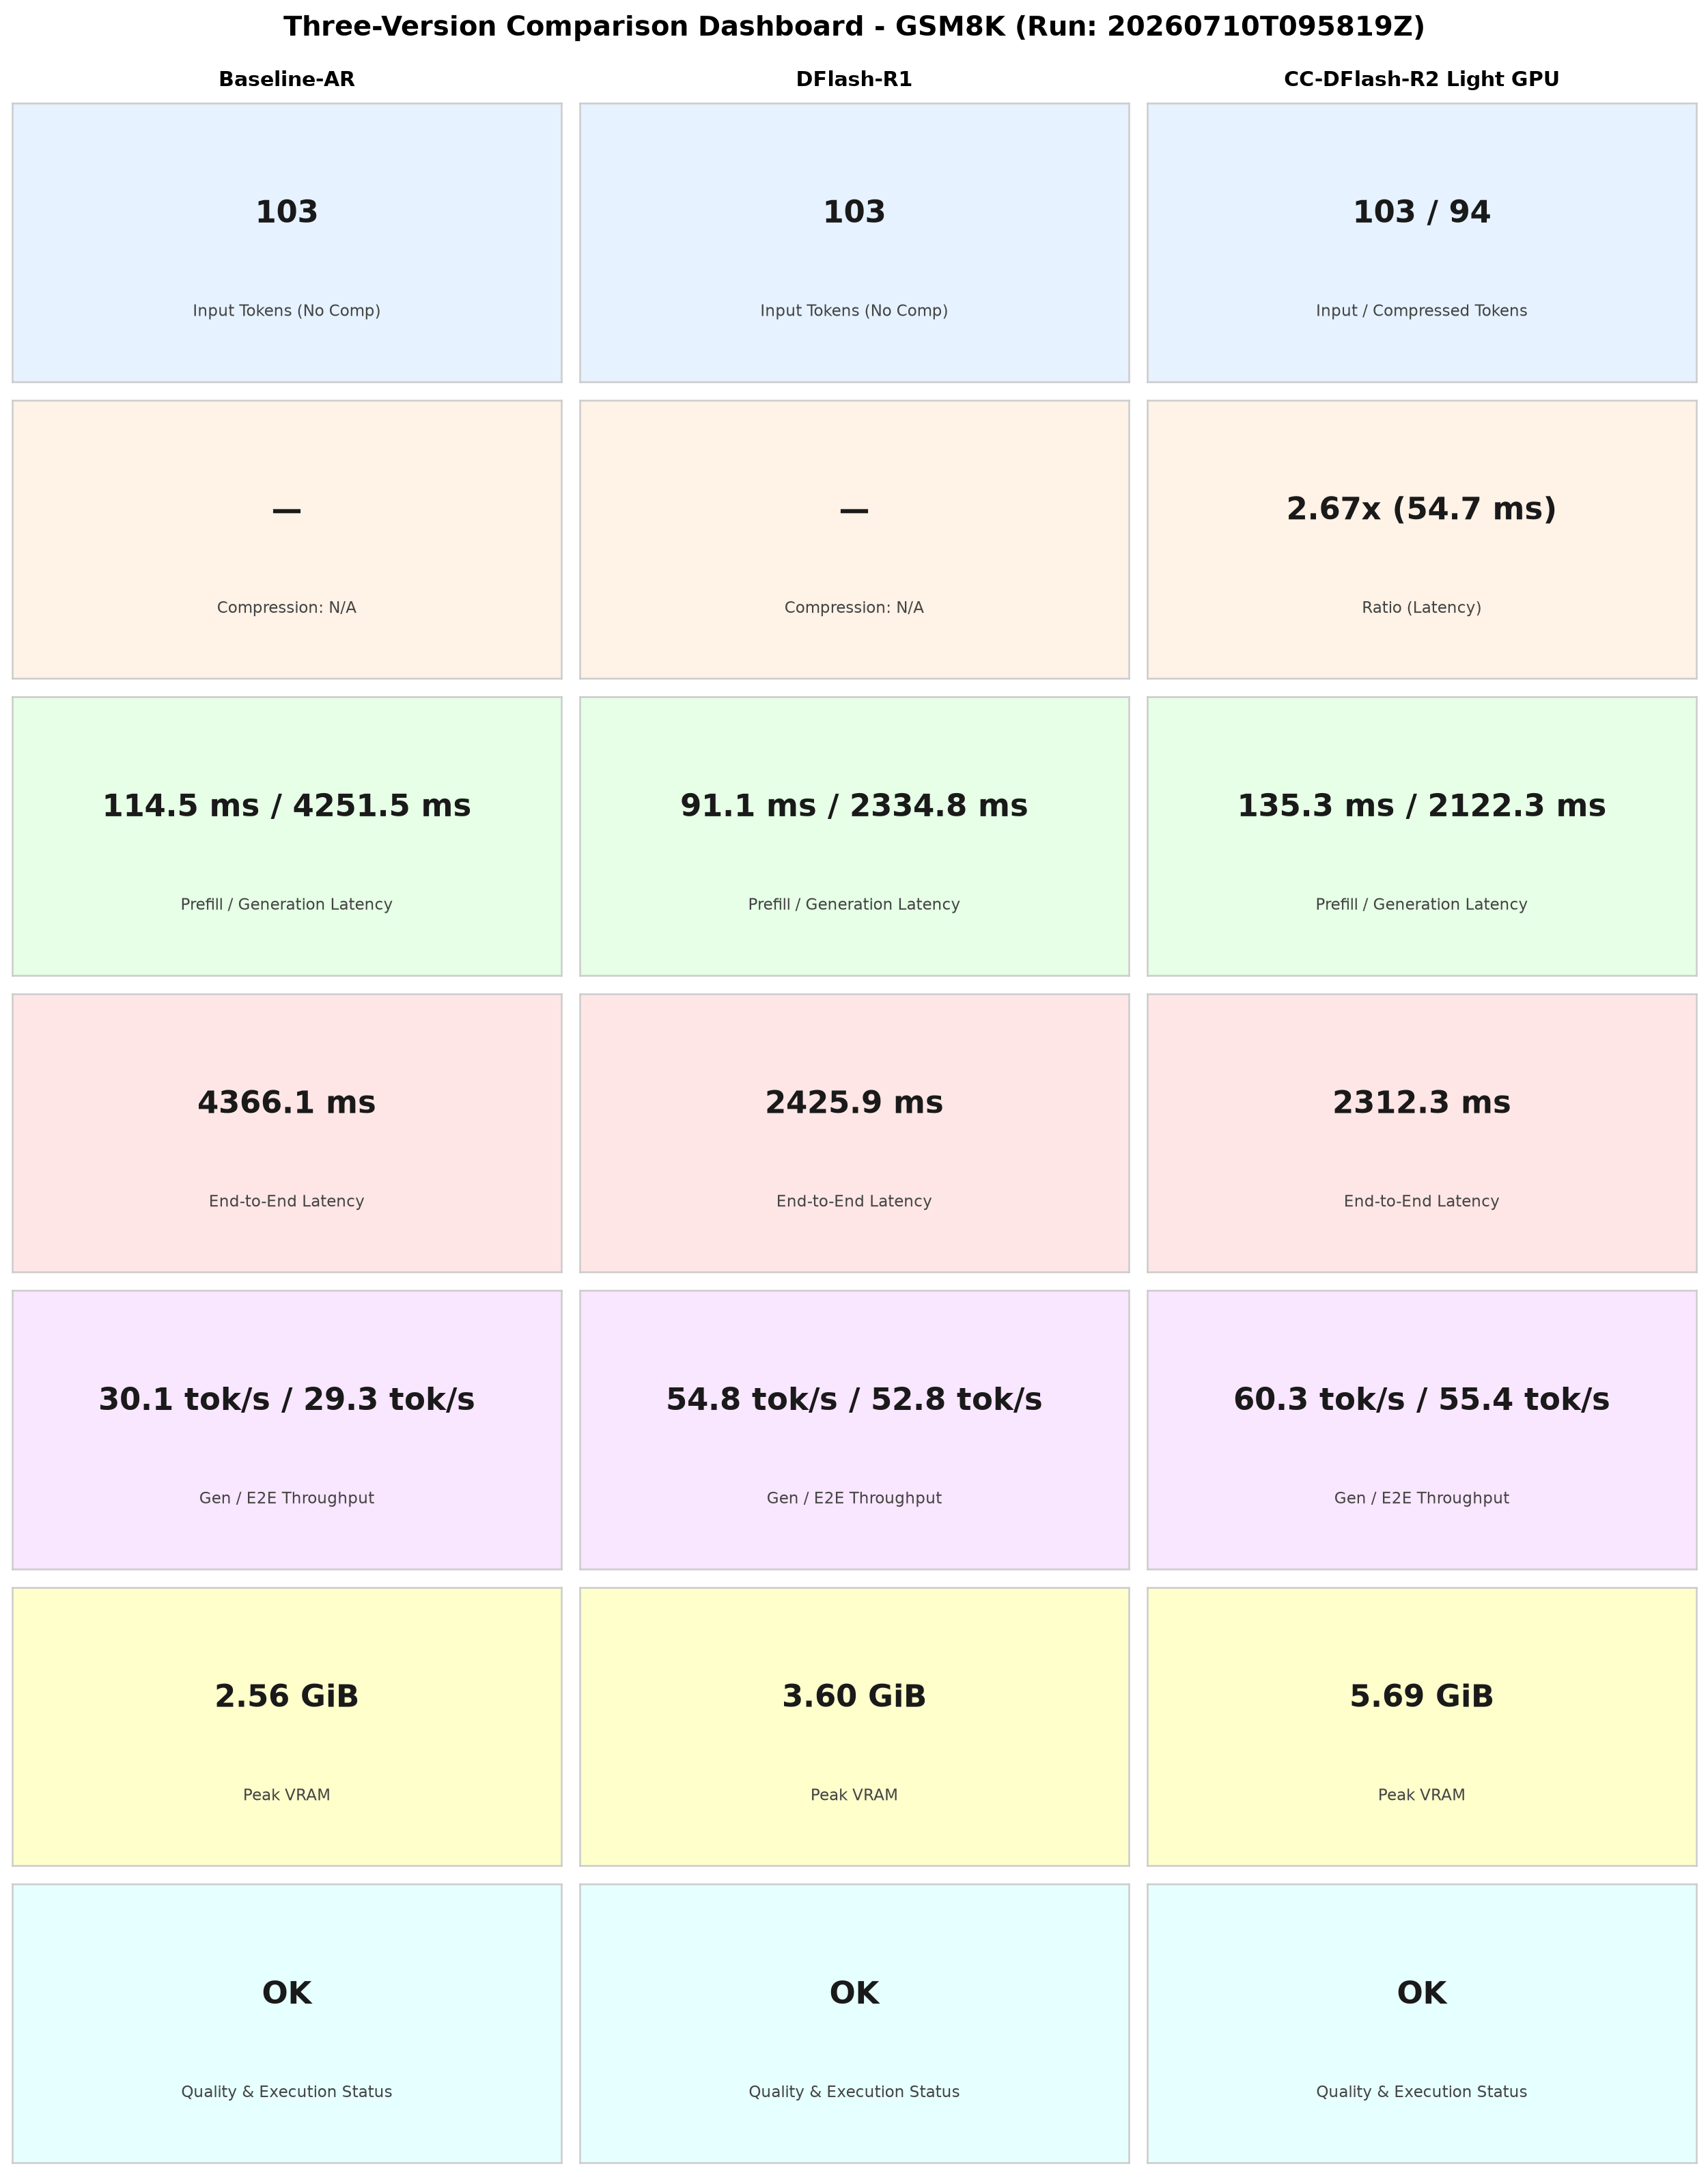

Saved dashboard: /data/Projects/CCDF/results/charts/notebook_demo/20260710T095819Z/charts/three_version_comparison_dashboard.png


In [6]:
dashboard_path = FIGURE_DIR / "three_version_comparison_dashboard.png"
dashboard_figure.savefig(
    dashboard_path,
    dpi=180,
    bbox_inches="tight"
)

display(dashboard_figure)
print(f"Saved dashboard: {dashboard_path}")

plt.show()
plt.close(dashboard_figure)

## Final Interpretation and Output Path

- The composite dashboard has been saved to: `results/charts/notebook_demo/{{RUN_ID}}/charts/three_version_comparison_dashboard.png`.
- Quality indicators on QMSum do not claim semantic correctness. The semantic correctness of the target model's output remains a final limitation.